<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#初等関数" data-toc-modified-id="初等関数-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>初等関数</a></span><ul class="toc-item"><li><span><a href="#ラジアンと角度(lost)" data-toc-modified-id="ラジアンと角度(lost)-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>ラジアンと角度(lost)</a></span></li></ul></li><li><span><a href="#ユーザ定義関数" data-toc-modified-id="ユーザ定義関数-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>ユーザ定義関数</a></span><ul class="toc-item"><li><span><a href="#簡単な定義" data-toc-modified-id="簡単な定義-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>簡単な定義</a></span></li><li><span><a href="#もう少し一般的な定義" data-toc-modified-id="もう少し一般的な定義-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>もう少し一般的な定義</a></span></li><li><span><a href="#より厳密な定義" data-toc-modified-id="より厳密な定義-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>より厳密な定義</a></span></li></ul></li></ul></div>

# 初等関数

四則演算は”＋ー＊・”．分数は，

In [1]:

from sympy import Rational

print(3/4);

0.75


であるが，Rational(有理数)というコマンドを使うと

In [2]:
Rational(3/4)

3/4

 と，分数のまま表示してくれる．

sympyを使うと$x$を変数として，そのままの記号で使うことが可能となる．ちょっと変な記述だが，

In [3]:
from sympy import symbols, pprint, sqrt, log, sin, cos, pi, N

x = symbols('a')
eq1 = 3*x**2 -4*x + 3
pprint(eq1)

   2          
3⋅a  - 4⋅a + 3


とすると変数名としてのxとそこに割り当てられた記号としての$a$の関係がわかるだろう．

その他の関数もそのまま直感的な名前が使える．

In [4]:
pprint(sqrt(2))

√2


In [5]:
pprint(log(x))

log(a)


In [6]:
pprint(sin(x)**2+cos(x)**2)

   2         2   
sin (a) + cos (a)


値として取り出すのは，以下のふた通り．

In [7]:
print( pi.evalf() )
print( N(pi, 100) )

3.14159265358979
3.141592653589793238462643383279502884197169399375105820974944592307816406286208998628034825342117068


## ラジアンと角度(lost)

mpmathをいれないと駄目？　でも，mpmathの説明があまりまともにされてない．
数値計算だよね．

degreesとかradiansに関しては，sympyで用意されてないようだ．

In [8]:
from math import *
degrees(pi/3)

59.99999999999999

In [9]:
radians(60)

1.0471975511965976

In [10]:
cos(pi/3)

0.5000000000000001

In [11]:
from sympy import cos, pi

cos(pi/3)

1/2

In [12]:
pprint(pi)

π


In [13]:
print(Rational(1/3))


6004799503160661/18014398509481984


SympyではRational, Real, Integerが数としてあるらしい．

Pi/3などをrationalとしては扱えない．したがって，三角関数の変形ではミスることになるな．
んーーーん．ちとしんどいかも．

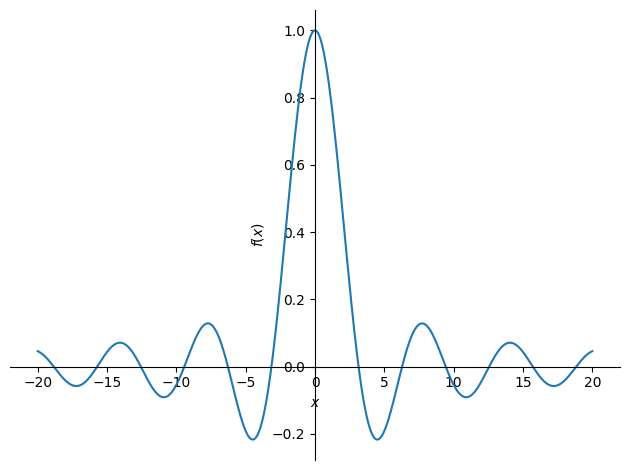

In [14]:
%matplotlib inline

from sympy import symbols
from sympy.plotting import plot
from sympy import sin, sinc

x = symbols('x')
plot(sinc(x), (x, -20, 20))

In [15]:
from sympy import acos, oo, pi
acos(oo)

oo*I

In [16]:
acos(0)

pi/2

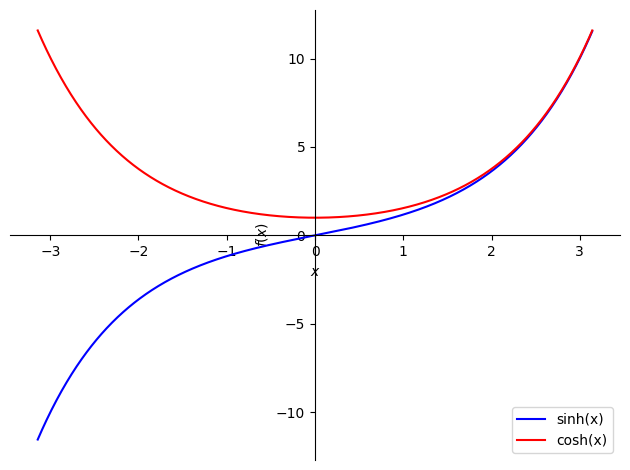

In [17]:
from sympy import *
x = symbols('x')
p1 = plot(sinh(x), cosh(x), (x,-pi,pi),
         legend=True, show=False)
p1[0].line_color = 'b'
p1[1].line_color = 'r'
p1.show()

# ユーザ定義関数
## 簡単な定義
単純にユーザが関数を定義するには下の通りすれば良い．その場合，入力はsubsを使う．

In [18]:
my_func = 2*x - 3

In [19]:
from sympy import *
a, x = symbols('a x')
pprint(my_func.subs({x:x}))
pprint(my_func.subs({x:a}))


2⋅x - 3
2⋅a - 3


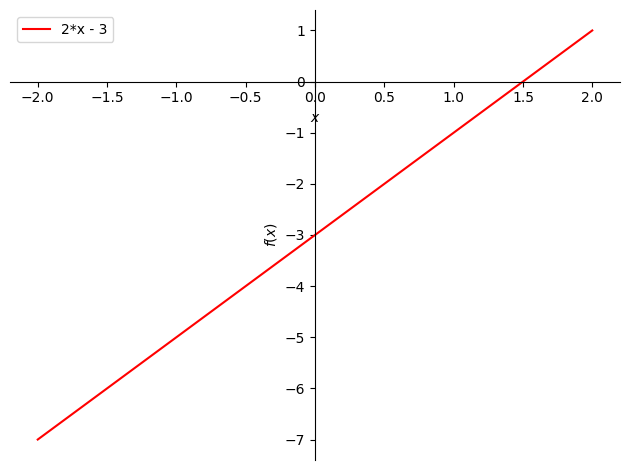

In [20]:
from sympy.plotting import plot
p1 = plot(my_func, (x,-2,2),
         legend=True, show=False)
p1[0].line_color = 'r'
p1.show()

## もう少し一般的な定義
Python　標準のdefを使うことも可能．

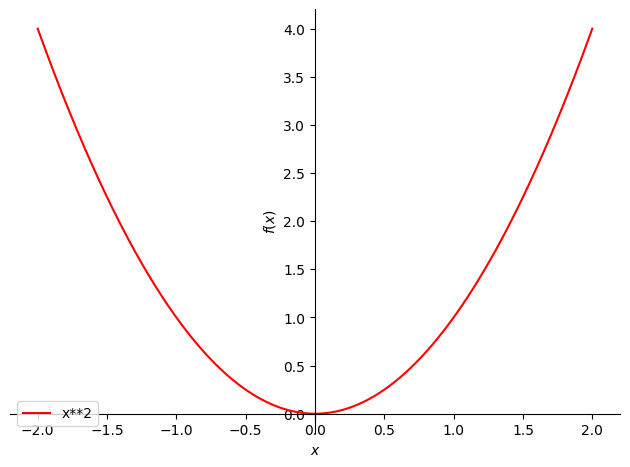

In [21]:
from sympy import *
x = symbols('x')

def func(x):
    return x**2

p1 = plot(func(x), (x,-2,2),
         legend=True, show=False)
p1[0].line_color = 'r'
p1.show()

In [22]:
integrate(func(x),x)

x**3/3

## より厳密な定義

より厳密に関数を定義するにはFunctionで定義する必要がある．

In [23]:
f = Function('f')

In [24]:
pprint(Derivative(f(x),x))

d       
──(f(x))
dx      


In [25]:
?Function

Init signature: Function(*args)
Docstring:     
Base class for applied mathematical functions.

It also serves as a constructor for undefined function classes.

See the :ref:`custom-functions` guide for details on how to subclass
``Function`` and what methods can be defined.

Examples

**Undefined Functions**

To create an undefined function, pass a string of the function name to
``Function``.

>>> from sympy import Function, Symbol
>>> x = Symbol('x')
>>> f = Function('f')
>>> g = Function('g')(x)
>>> f
f
>>> f(x)
f(x)
>>> g
g(x)
>>> f(x).diff(x)
Derivative(f(x), x)
>>> g.diff(x)
Derivative(g(x), x)

Assumptions can be passed to ``Function`` the same as with a
:class:`~.Symbol`. Alternatively, you can use a ``Symbol`` with
assumptions for the function name and the function will inherit the name
and assumptions associated with the ``Symbol``:

>>> f_real = Function('f', real=True)
>>> f_real(x).is_real
True
>>> f_real_inherit = Function(Symbol('f', real=True))
>>> f_real_inherit(x).is_

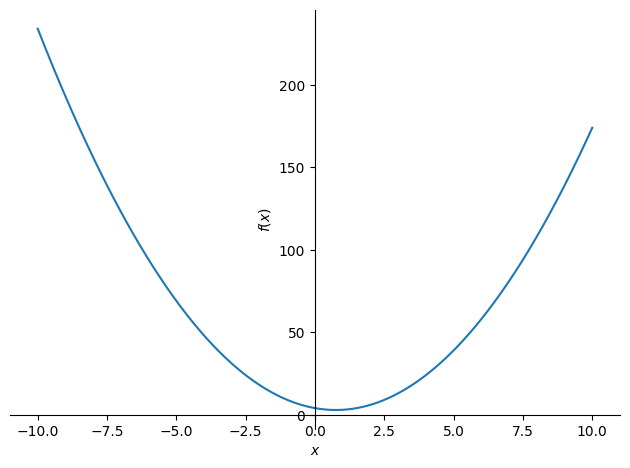

In [26]:
class my_func(Function):
    @classmethod
    def eval(cls, x):
        return 2*x**2-3*x+4

plot(my_func(x))

In [27]:
diff(my_func(x),x)

4*x - 3

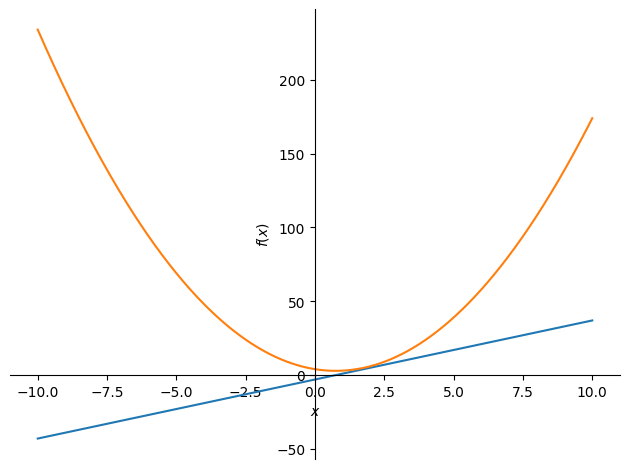

In [28]:
plot(diff(my_func(x),x),my_func(x))